In [ ]:
import pandas as pd

df = pd.read_csv("accident_prediction_india.csv")
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   State Name                   3000 non-null   object
 1   City Name                    3000 non-null   object
 2   Year                         3000 non-null   int64 
 3   Month                        3000 non-null   object
 4   Day of Week                  3000 non-null   object
 5   Time of Day                  3000 non-null   object
 6   Accident Severity            3000 non-null   object
 7   Number of Vehicles Involved  3000 non-null   int64 
 8   Vehicle Type Involved        3000 non-null   object
 9   Number of Casualties         3000 non-null   int64 
 10  Number of Fatalities         3000 non-null   int64 
 11  Weather Conditions           3000 non-null   object
 12  Road Type                    3000 non-null   object
 13  Road Condition               3000

,Year,Number of Vehicles Involved,Number of Casualties,Number of Fatalities,Speed Limit (km/h),Driver Age
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,2020.530000,2.996000,5.066000,2.455333,74.940667,44.17700
std,1.683858,1.428285,3.214097,1.717650,26.765088,15.40286
min,2018.000000,1.000000,0.000000,0.000000,30.000000,18.00000
25%,2019.000000,2.000000,2.000000,1.000000,51.000000,31.00000
50%,2021.000000,3.000000,5.000000,2.000000,75.000000,45.00000
75%,2022.000000,4.000000,8.000000,4.000000,99.000000,57.00000
max,2023.000000,5.000000,10.000000,5.000000,120.000000,70.00000


In [ ]:
df.isnull().sum()


,0
State Name,0
City Name,0
Year,0
Month,0
Day of Week,0
Time of Day,0
Accident Severity,0
Number of Vehicles Involved,0
Vehicle Type Involved,0
Number of Casualties,0


In [ ]:
df.columns


Index(['State Name', 'City Name', 'Year', 'Month', 'Day of Week',
       'Time of Day', 'Accident Severity', 'Number of Vehicles Involved',
       'Vehicle Type Involved', 'Number of Casualties', 'Number of Fatalities',
       'Weather Conditions', 'Road Type', 'Road Condition',
       'Lighting Conditions', 'Traffic Control Presence', 'Speed Limit (km/h)',
       'Driver Age', 'Driver Gender', 'Driver License Status',
       'Alcohol Involvement', 'Accident Location Details'],
      dtype='object')

In [ ]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + "-" +
    df['Month'].astype(str) + "-1"
)


In [ ]:
df['Time of Day'] = df['Time of Day'].astype(str)

df['Hour'] = pd.to_datetime(df['Time of Day'], format='%H:%M', errors='coerce').dt.hour


In [ ]:
df['Hour'] = pd.to_datetime(df['Time of Day'], format='%I:%M %p', errors='coerce').dt.hour


In [ ]:
df['Time of Day'].head()


,Time of Day
0,1:46
1,21:30
2,5:37
3,0:31
4,11:21


In [ ]:
df['Time of Day'] = df['Time of Day'].astype(str)

df['Hour'] = pd.to_datetime(
    df['Time of Day'],
    format='%H:%M',
    errors='coerce'
).dt.hour


In [ ]:
def time_range(h):
    if 5 <= h < 12:
        return "Morning (5 AM–11:59 AM)"
    elif 12 <= h < 17:
        return "Afternoon (12 PM–4:59 PM)"
    elif 17 <= h < 21:
        return "Evening (5 PM–8:59 PM)"
    else:
        return "Night (9 PM–4:59 AM)"

df['Time Range'] = df['Hour'].apply(time_range)


<Axes: xlabel='Hour'>

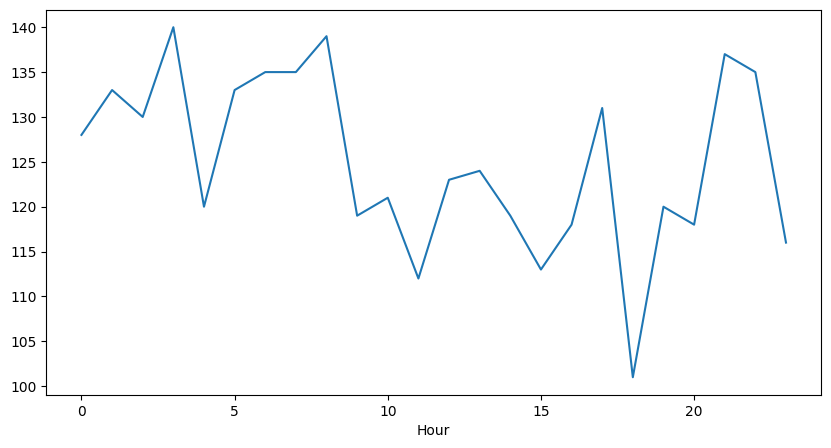

In [ ]:
df['Hour'].value_counts().sort_index().plot(kind='line', figsize=(10,5))


<Axes: xlabel='Time Range'>

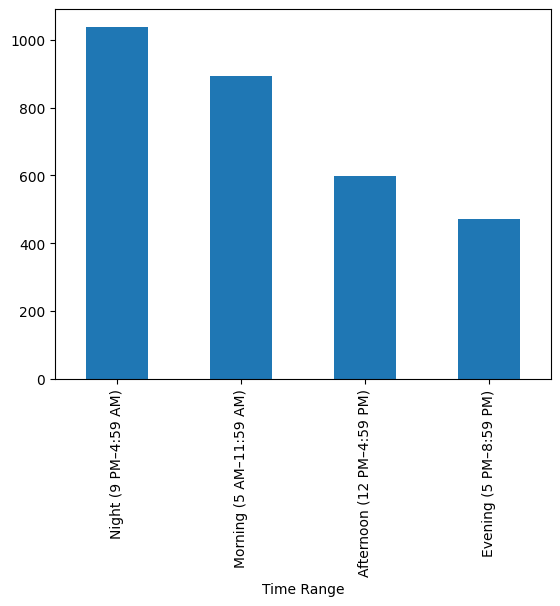

In [ ]:
df['Time Range'].value_counts().plot(kind='bar')


In [ ]:
df['Day of Week'] = df['Day of Week'].str.strip().str.title()


In [ ]:
df['Month'] = df['Month'].astype(str).str.strip().str.title()
df['Month Name'] = df['Month']


In [ ]:
df['Month'].unique()


array(['May', 'January', 'June', 'August', 'November', 'October',
       'December', 'July', 'April', 'September', 'February', 'March'],
      dtype=object)

In [ ]:
df['Month'] = df['Month'].astype(str).str.strip().str.title()


In [ ]:
df['Month Name'] = df['Month']


In [ ]:
import calendar

month_map = {month: idx for idx, month in enumerate(calendar.month_name) if month}

df['Month Number'] = df['Month Name'].map(month_map)


In [ ]:
df['Weather Conditions'] = (
    df['Weather Conditions']
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({
        'sunny ': 'sunny',
        'rain ': 'rain',
        'rainy': 'rain',
        'cloudy ': 'cloudy',
        'fog ': 'fog',
        'none': 'none',
        'clear': 'sunny',
        'clear sky': 'sunny'
    })
)


In [ ]:
df['Road Condition'] = (
    df['Road Condition']
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({
        'wet ': 'wet',
        'wet road': 'wet',
        'dry road': 'dry',
        'water logged': 'waterlogged',
        'snow ': 'snow',
        'icy ': 'icy'
    })
)



In [ ]:
df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   State Name                   3000 non-null   object        
 1   City Name                    3000 non-null   object        
 2   Year                         3000 non-null   int64         
 3   Month                        3000 non-null   object        
 4   Day of Week                  3000 non-null   object        
 5   Time of Day                  3000 non-null   object        
 6   Accident Severity            3000 non-null   object        
 7   Number of Vehicles Involved  3000 non-null   int64         
 8   Vehicle Type Involved        3000 non-null   object        
 9   Number of Casualties         3000 non-null   int64         
 10  Number of Fatalities         3000 non-null   int64         
 11  Weather Conditions           3000 non-null 

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details,Date,Hour,Time Range,Month Name,Month Number
count,3000,3000,3000.000000,3000,3000,3000,3000,3000.000000,3000,3000.000000,...,3000.00000,3000,2025,3000,3000,3000,3000.000000,3000,3000,3000.000000
unique,32,28,NaN,12,7,1263,3,NaN,7,NaN,...,NaN,2,2,2,4,NaN,NaN,4,12,NaN
top,Goa,Unknown,NaN,March,Wednesday,3:40,Minor,NaN,Truck,NaN,...,NaN,Female,Valid,Yes,Intersection,NaN,NaN,Night (9 PM–4:59 AM),March,NaN
freq,109,2138,NaN,266,468,7,1034,NaN,449,NaN,...,NaN,1563,1057,1520,789,NaN,NaN,1039,266,NaN
mean,NaN,NaN,2020.530000,NaN,NaN,NaN,NaN,2.996000,NaN,5.066000,...,44.17700,NaN,NaN,NaN,NaN,2020-12-27 02:02:52.799999744,11.291667,NaN,NaN,6.516000
min,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000,...,18.00000,NaN,NaN,NaN,NaN,2018-01-01 00:00:00,0.000000,NaN,NaN,1.000000
25%,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN,2.000000,NaN,2.000000,...,31.00000,NaN,NaN,NaN,NaN,2019-08-01 00:00:00,5.000000,NaN,NaN,3.000000
50%,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,3.000000,NaN,5.000000,...,45.00000,NaN,NaN,NaN,NaN,2021-01-01 00:00:00,11.000000,NaN,NaN,6.000000
75%,NaN,NaN,2022.000000,NaN,NaN,NaN,NaN,4.000000,NaN,8.000000,...,57.00000,NaN,NaN,NaN,NaN,2022-06-01 00:00:00,17.000000,NaN,NaN,10.000000
max,NaN,NaN,2023.000000,NaN,NaN,NaN,NaN,5.000000,NaN,10.000000,...,70.00000,NaN,NaN,NaN,NaN,2023-12-01 00:00:00,23.000000,NaN,NaN,12.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
!pip install seaborn


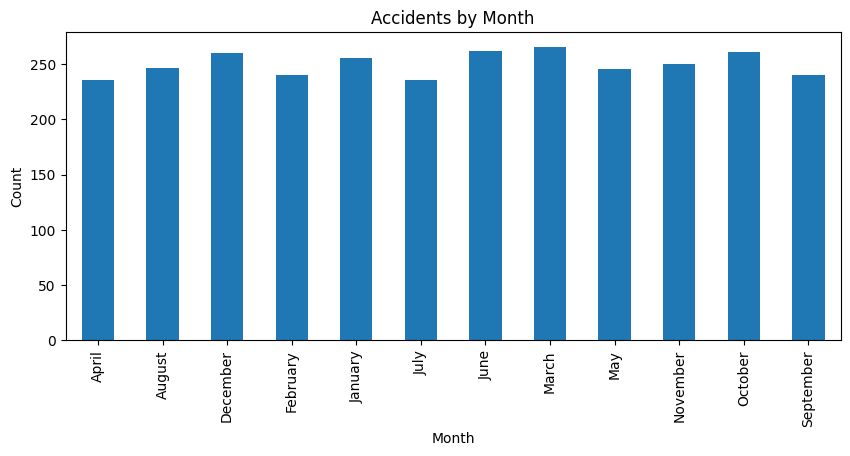

In [ ]:
df['Month'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))
plt.title("Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()


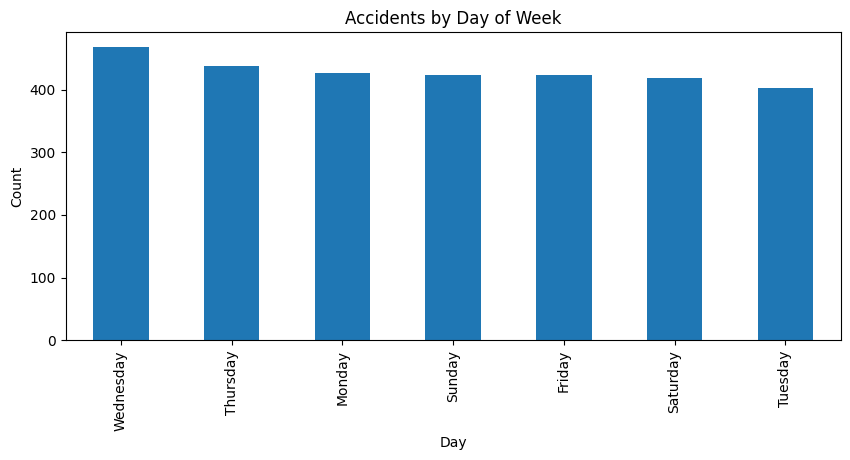

In [ ]:
df['Day of Week'].value_counts().plot(kind='bar', figsize=(10,4))
plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()


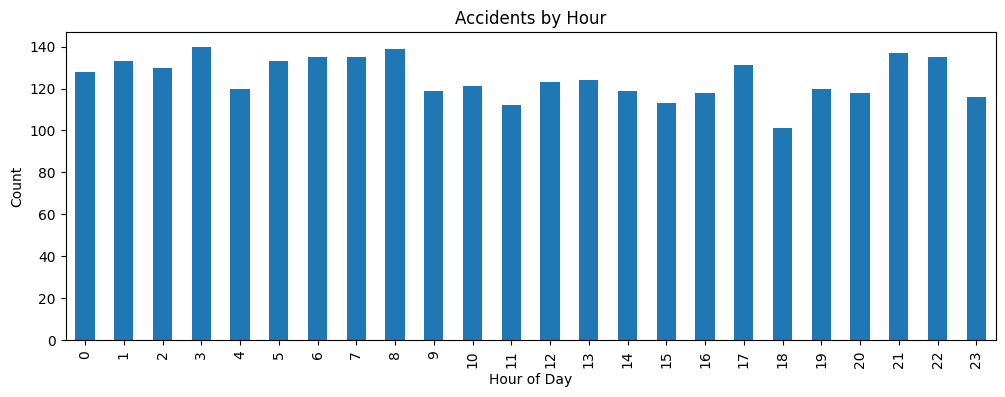

In [ ]:
df['Hour'].value_counts().sort_index().plot(kind='bar', figsize=(12,4))
plt.title("Accidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.show()


In [ ]:
df.columns


Index(['State Name', 'City Name', 'Year', 'Month', 'Day of Week',
       'Time of Day', 'Accident Severity', 'Number of Vehicles Involved',
       'Vehicle Type Involved', 'Number of Casualties', 'Number of Fatalities',
       'Weather Conditions', 'Road Type', 'Road Condition',
       'Lighting Conditions', 'Traffic Control Presence', 'Speed Limit (km/h)',
       'Driver Age', 'Driver Gender', 'Driver License Status',
       'Alcohol Involvement', 'Accident Location Details', 'Date', 'Hour',
       'Time Range', 'Month Name', 'Month Number'],
      dtype='object')

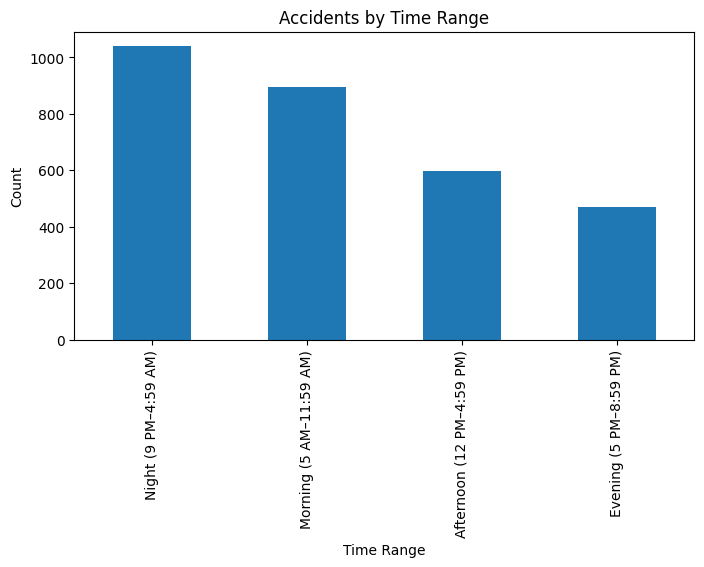

In [ ]:
df['Time Range'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title("Accidents by Time Range")
plt.xlabel("Time Range")
plt.ylabel("Count")
plt.show()


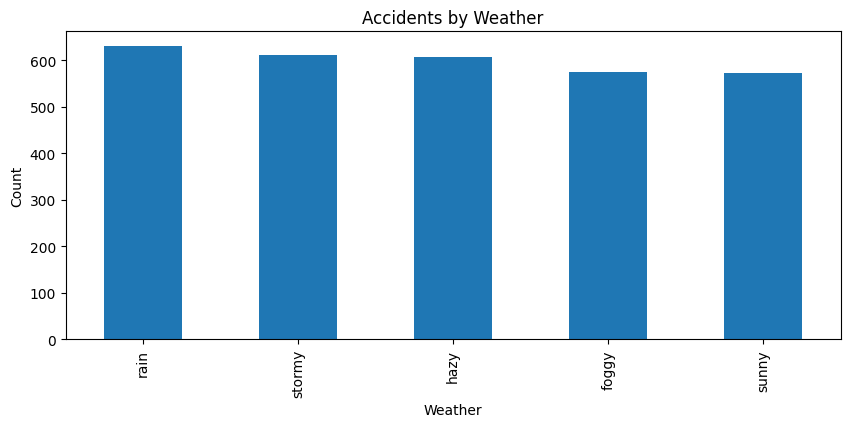

In [ ]:
df['Weather Conditions'].value_counts().plot(kind='bar', figsize=(10,4))
plt.title("Accidents by Weather")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.show()


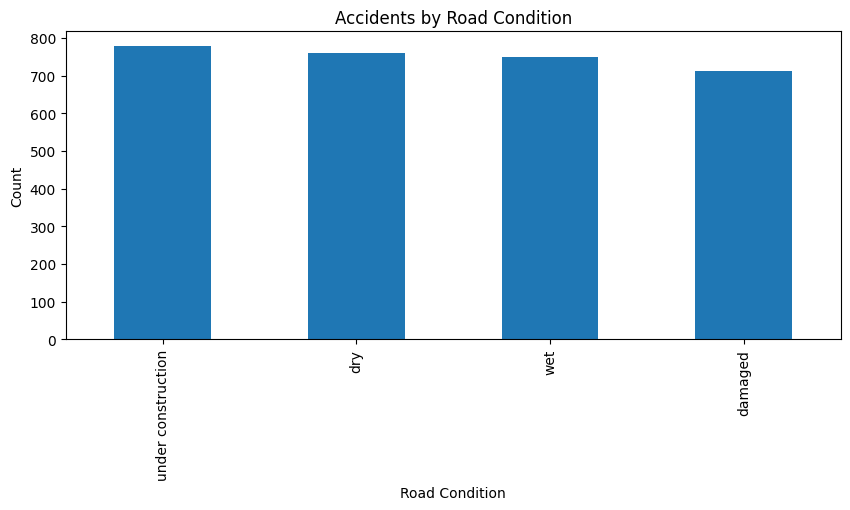

In [ ]:
df['Road Condition'].value_counts().plot(kind='bar', figsize=(10,4))
plt.title("Accidents by Road Condition")
plt.xlabel("Road Condition")
plt.ylabel("Count")
plt.show()


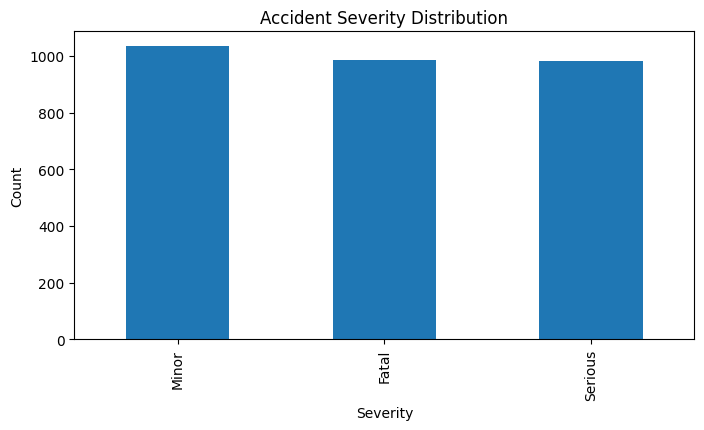

In [ ]:
df['Accident Severity'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()


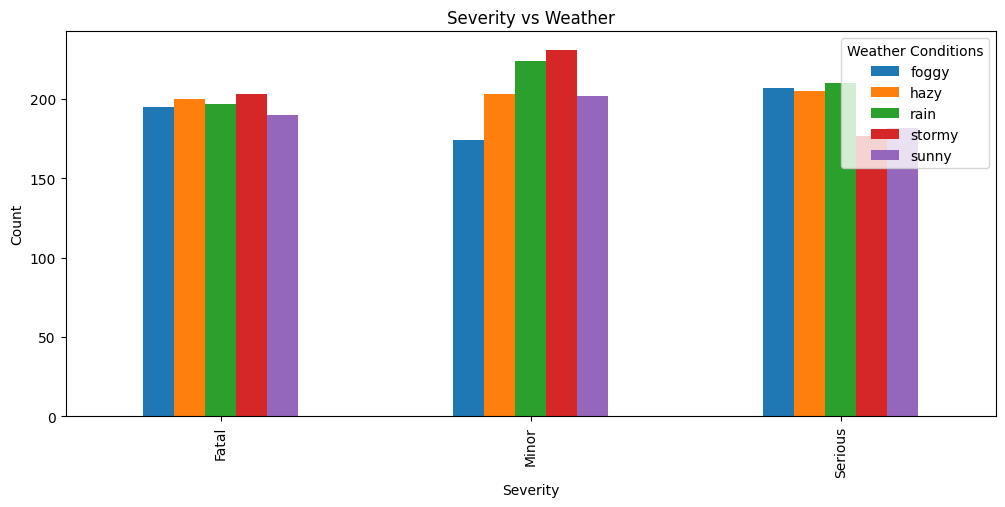

In [ ]:
pd.crosstab(df['Accident Severity'], df['Weather Conditions']).plot(kind='bar', figsize=(12,5))
plt.title("Severity vs Weather")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()


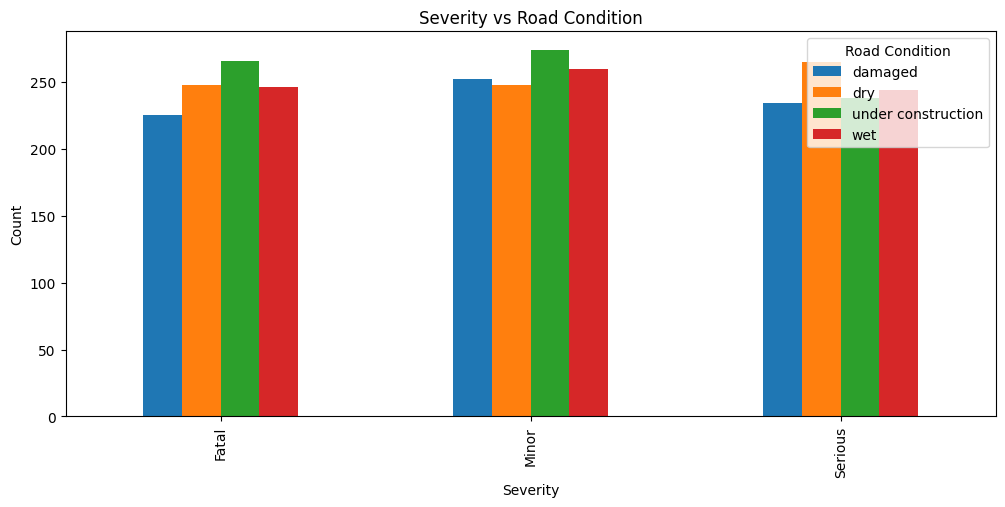

In [ ]:
pd.crosstab(df['Accident Severity'], df['Road Condition']).plot(kind='bar', figsize=(12,5))
plt.title("Severity vs Road Condition")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()


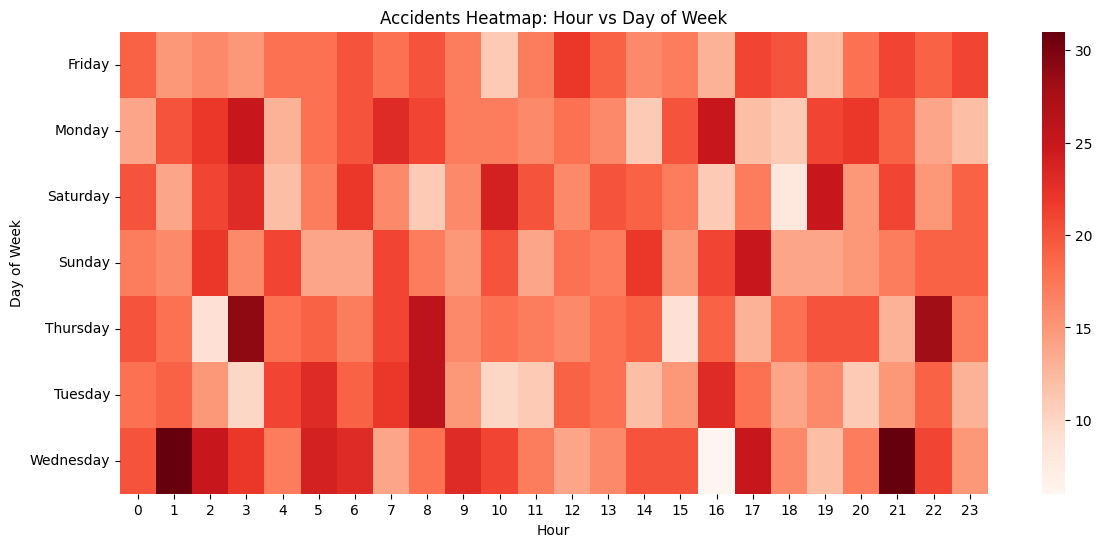

In [ ]:
import seaborn as sns
pivot_table = df.pivot_table(index='Day of Week', columns='Hour', values='Accident Severity', aggfunc='count')

plt.figure(figsize=(14,6))
sns.heatmap(pivot_table, cmap='Reds')
plt.title("Accidents Heatmap: Hour vs Day of Week")
plt.show()


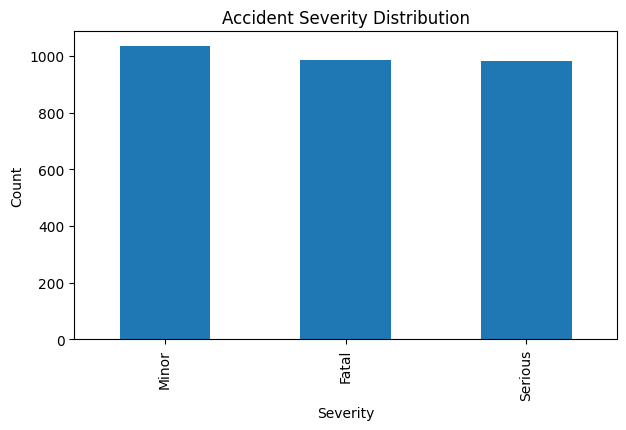

In [ ]:
df['Accident Severity'].value_counts().plot(kind='bar', figsize=(7,4))
plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()


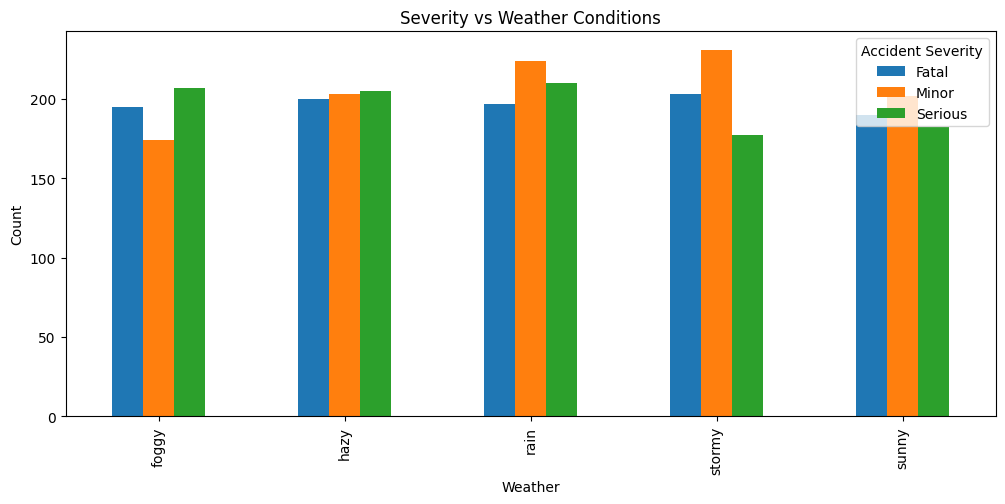

In [ ]:
pd.crosstab(df['Weather Conditions'], df['Accident Severity']).plot(kind='bar', figsize=(12,5))
plt.title("Severity vs Weather Conditions")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.show()


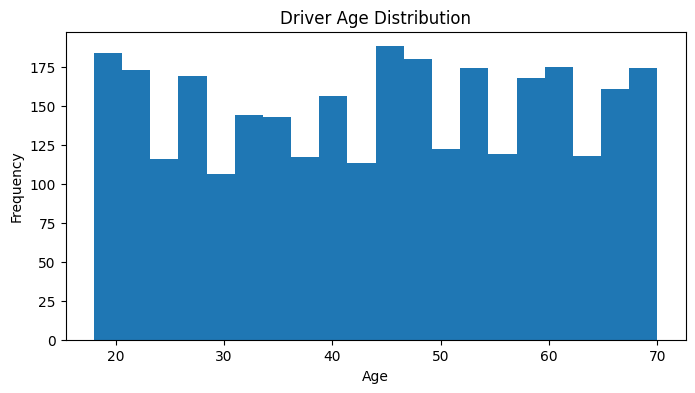

In [ ]:
df['Driver Age'].plot(kind='hist', bins=20, figsize=(8,4))
plt.title("Driver Age Distribution")
plt.xlabel("Age")
plt.show()


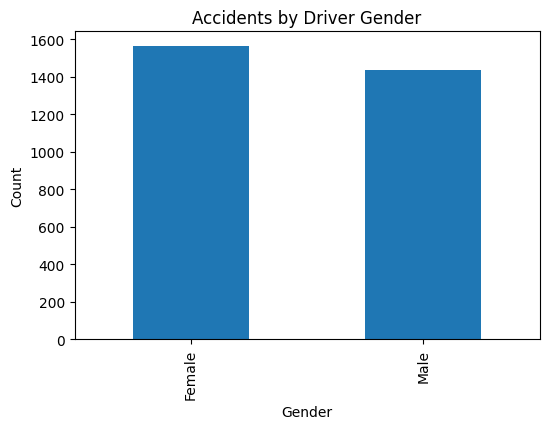

In [ ]:
df['Driver Gender'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Accidents by Driver Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


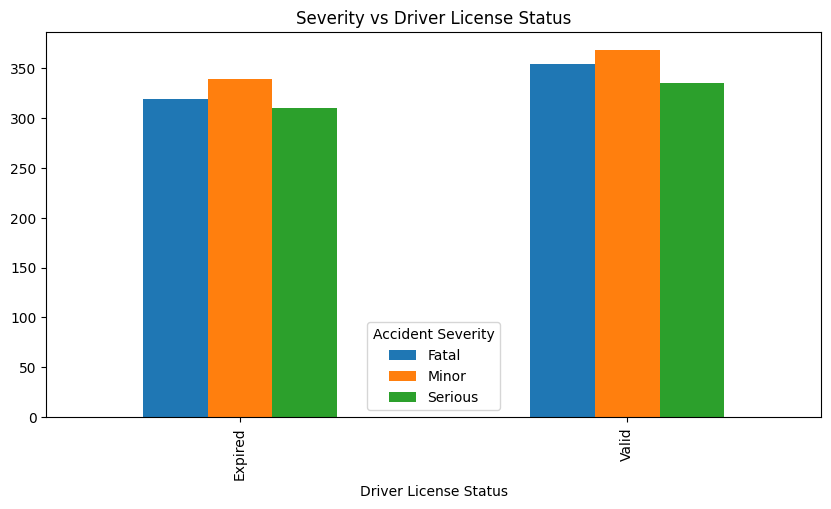

In [ ]:
pd.crosstab(df['Driver License Status'], df['Accident Severity']).plot(kind='bar', figsize=(10,5))
plt.title("Severity vs Driver License Status")
plt.show()


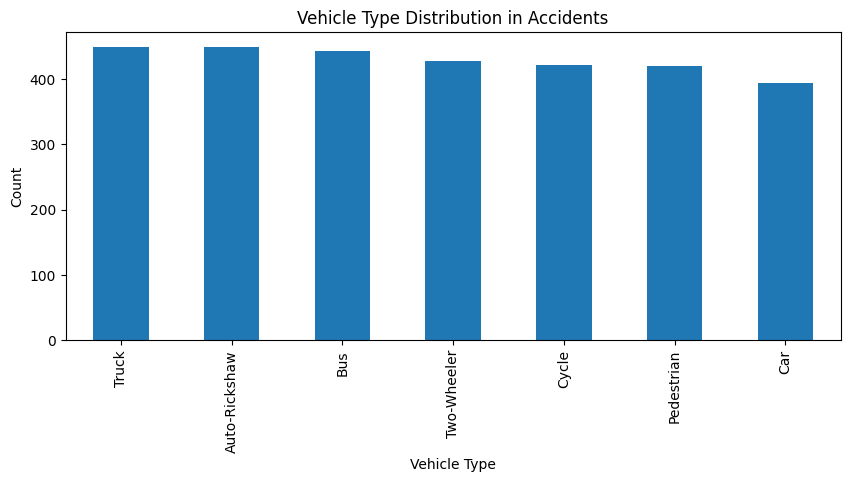

In [ ]:
df['Vehicle Type Involved'].value_counts().plot(kind='bar', figsize=(10,4))
plt.title("Vehicle Type Distribution in Accidents")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.show()


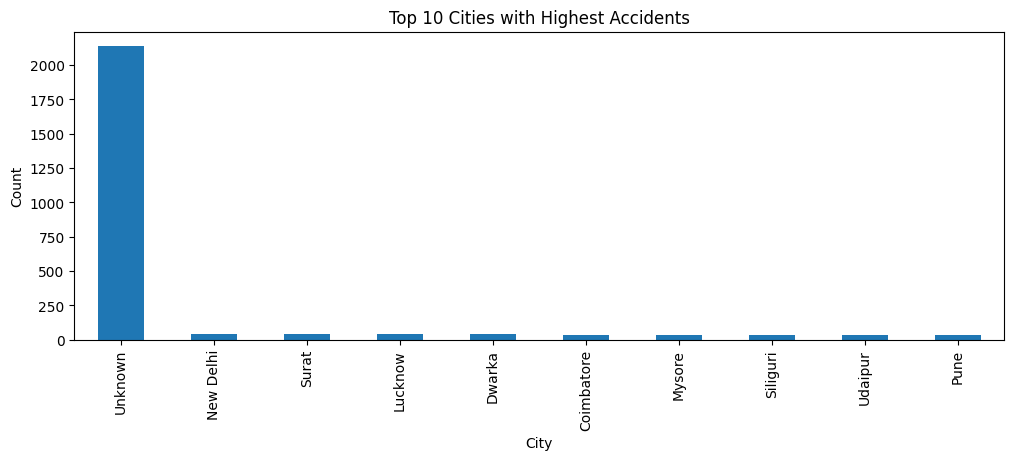

In [ ]:
df['City Name'].value_counts().head(10).plot(kind='bar', figsize=(12,4))
plt.title("Top 10 Cities with Highest Accidents")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()


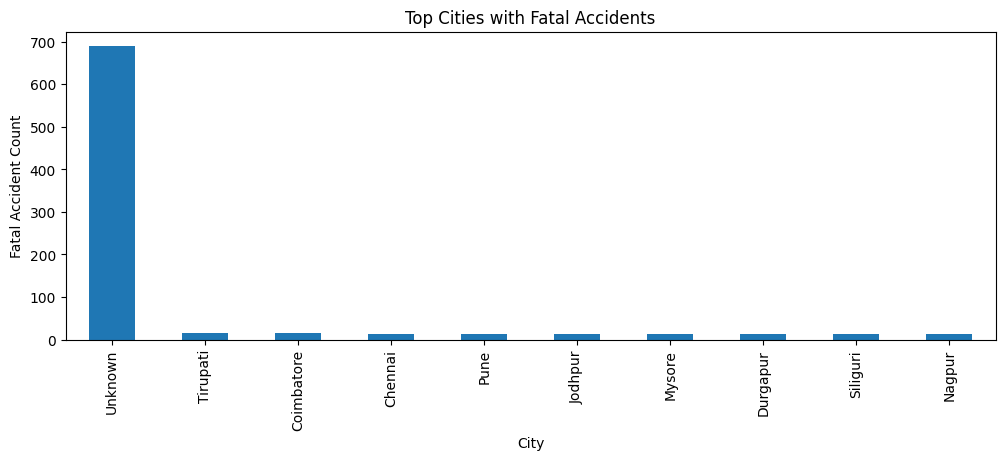

In [ ]:
fatal_cities = df[df['Accident Severity'] == 'Fatal']['City Name'].value_counts().head(10)
fatal_cities.plot(kind='bar', figsize=(12,4))
plt.title("Top Cities with Fatal Accidents")
plt.xlabel("City")
plt.ylabel("Fatal Accident Count")
plt.show()


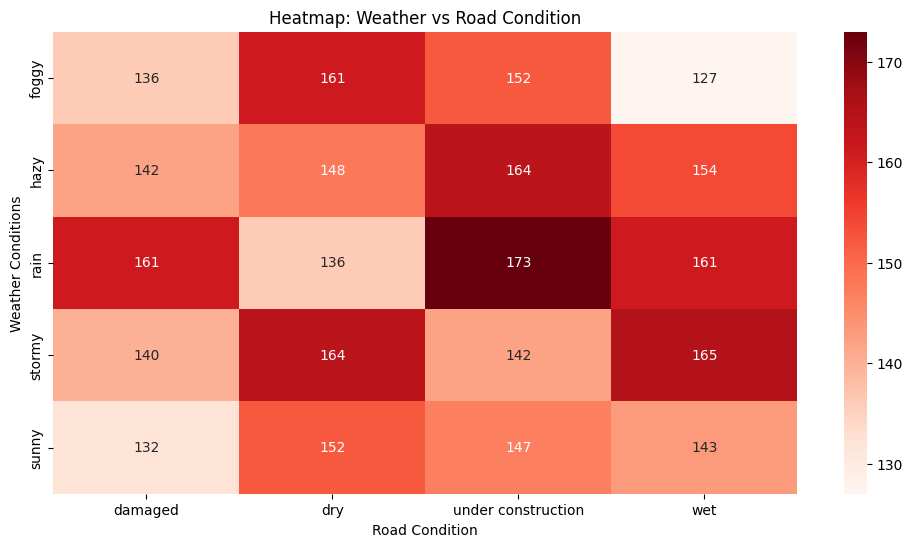

In [ ]:
pivot = df.pivot_table(
    index='Weather Conditions',
    columns='Road Condition',
    values='Accident Severity',
    aggfunc='count'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Reds", annot=True, fmt="g")
plt.title("Heatmap: Weather vs Road Condition")
plt.show()


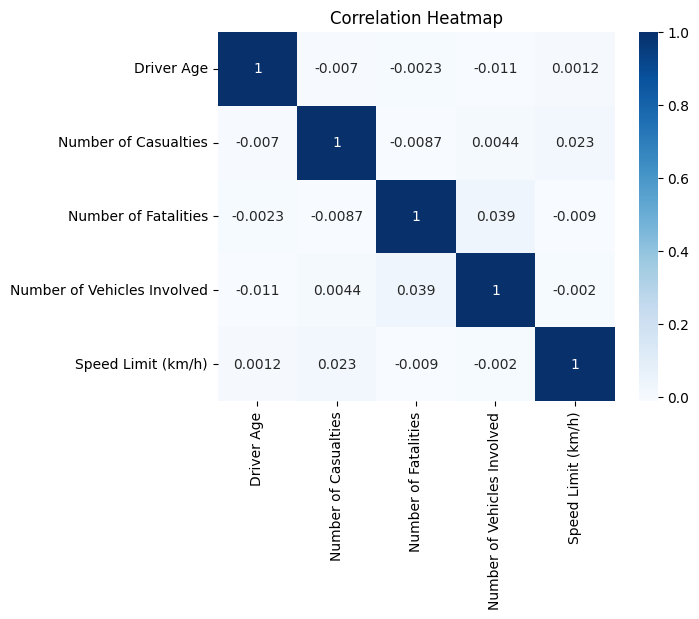

In [ ]:
numeric_df = df[['Driver Age', 'Number of Casualties', 'Number of Fatalities', 'Number of Vehicles Involved', 'Speed Limit (km/h)']]
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
df.to_csv("cleaned_accidents.csv", index=False)


In [ ]:
from google.colab import files
files.download("cleaned_accidents.csv")


FileNotFoundError: Cannot find file: cleaned_accidents.csv